# Chapter 7. 토픽 모델링으로 주제 찾기

## 1. 토픽 모델링의 이해

1: https://mobile.newsis.com/view.html?ar_id=NISX20190918_0000772783#_enliple
2: https://cyram.tistory.com/309

### 1.1 LDA(Latent Dirichlet Allocation)



### 1.2 모형의 평가와 적절한 토픽 수의 결정


## 2. 사이킷런을 이용한 토픽 모델링

### 2.1 데이터 준비



In [ ]:
import warnings
import logging

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore")

logging.getLogger().setLevel(logging.ERROR)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('webtext')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package webtext to /root/nltk_data...
[nltk_data]   Package webtext is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [ ]:
from sklearn.datasets import fetch_20newsgroups

categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space',
              'comp.sys.ibm.pc.hardware', 'sci.crypt']


In [ ]:
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories)

print('#Train set size:', len(newsgroups_train.data))
print('#Selected categories:', newsgroups_train.target_names)

#Train set size: 3219
#Selected categories: ['alt.atheism', 'comp.graphics', 'comp.sys.ibm.pc.hardware', 'sci.crypt', 'sci.space', 'talk.religion.misc']


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(token_pattern=r"[\w']{3,}", stop_words='english',\
                     max_features=2000, min_df=5, max_df=0.5)
review_cv = cv.fit_transform(newsgroups_train.data)

print('review_cv', review_cv.shape)

review_cv (3219, 2000)


### 2.2 LDA 토픽 모델링 실행


1: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html <br>
2: Griffiths, Thomas L., and Mark Steyvers. "Finding scientific topics." Proceedings of the National academy of Sciences 101.suppl 1 (2004): 5228-5235.

In [ ]:
#
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
np.set_printoptions(precision=3)

lda = LatentDirichletAllocation(n_components = 10,
                                max_iter=5,
                                topic_word_prior=0.1,
                                doc_topic_prior=1.0,
                                learning_method='online',
                                n_jobs= -1,
                                random_state=0)

review_topics = lda.fit_transform(review_cv)


# 문서별 토픽 분포(세타)
print('#shape of review_topics:', review_topics.shape)
print('#Sample of review_topics:', review_topics[0])


# 모든 문서에 나타난 토픽의 평균 분포
gross_topic_weights = np.mean(review_topics, axis=0)

print('#Sum of topic weights of documents:', gross_topic_weights)


# 토픽별 단어 분포(파이)
print('#shape of topic word distribution:', lda.components_.shape)

#shape of review_topics: (3219, 10)
#Sample of review_topics: [0.009 0.007 0.007 0.048 0.008 0.009 0.869 0.011 0.025 0.008]
#Sum of topic weights of documents: [0.145 0.077 0.088 0.146 0.077 0.069 0.08  0.112 0.104 0.101]
#shape of topic word distribution: (10, 2000)


In [ ]:
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print("Topic #%d: " % topic_idx, end='')
        print(", ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))
    print()

print_top_words(lda,cv.get_feature_names_out(), 10)

Topic #0: com, host, nntp, university, posting, thanks, know, ibm, i'm, help
Topic #1: university, article, posting, com, nntp, host, group, like, comp, graphics
Topic #2: image, file, available, data, ftp, information, files, mail, graphics, software
Topic #3: god, people, jesus, don't, does, believe, say, think, bible, just
Topic #4: drive, scsi, disk, ide, bus, controller, hard, drives, dos, tape
Topic #5: key, public, sandvik, number, com, des, bit, apple, message, keys
Topic #6: com, keith, morality, caltech, objective, sgi, moral, article, think, posting
Topic #7: com, just, like, don't, article, think, i'm, people, it's, really
Topic #8: space, nasa, gov, launch, access, earth, orbit, shuttle, digex, henry
Topic #9: clipper, chip, encryption, government, com, key, escrow, use, technology, law



### 2.3 최적의 토픽 수 선택하기


n_components: 6, perplexity: 1031.374
n_components: 7, perplexity: 1036.806
n_components: 8, perplexity: 1034.249
n_components: 9, perplexity: 1025.570
n_components: 10, perplexity: 1032.346
n_components: 11, perplexity: 1021.038
n_components: 12, perplexity: 1021.462
n_components: 13, perplexity: 1017.702
n_components: 14, perplexity: 1011.233
n_components: 15, perplexity: 1024.069


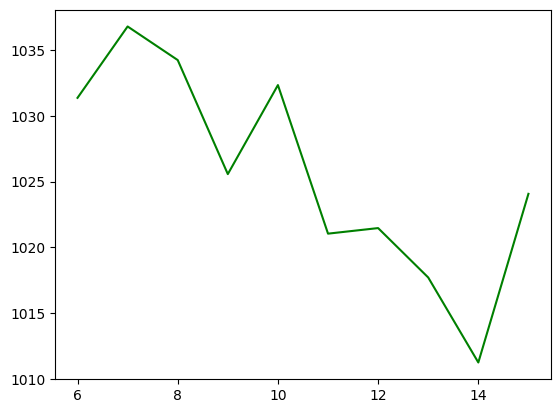

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


def show_perplexity(cv, start=10, end=30, max_iter=5, topic_word_prior= 0.1,doc_topic_prior=1.0):
    iter_num = []
    per_value = []

    for i in range(start, end + 1):
        lda = LatentDirichletAllocation(n_components = i, max_iter=max_iter,
                                        topic_word_prior= topic_word_prior,
                                        doc_topic_prior=doc_topic_prior,
                                        learning_method='batch', n_jobs= -1,
                                        random_state=7)
        lda.fit(cv)
        iter_num.append(i)
        pv = lda.perplexity(cv)
        per_value.append(pv)
        print(f'n_components: {i}, perplexity: {pv:0.3f}')

    plt.plot(iter_num, per_value, 'g-')
    plt.show()
    return start + per_value.index(min(per_value))

N_COMPONENTS = show_perplexity(review_cv, start=6, end=15)


In [ ]:
print('N_COMPONENTS:', N_COMPONENTS)

N_COMPONENTS: 14


In [ ]:
lda = LatentDirichletAllocation(n_components = N_COMPONENTS, #추출할 topic의 수를 지정
                                max_iter=20,
                                topic_word_prior= 0.1,
                                doc_topic_prior=1.0,
                                learning_method='batch',
                                n_jobs= -1,
                                random_state=7)

review_topics = lda.fit_transform(review_cv)

print_top_words(lda, cv.get_feature_names_out(), 10)

Topic #0: key, public, des, use, pgp, cryptography, ripem, rsa, message, faq
Topic #1: com, access, article, net, ibm, digex, netcom, pat, mark, like
Topic #2: drive, card, disk, hard, controller, drives, dos, memory, problem, use
Topic #3: com, say, jim, article, science, newsreader, morality, question, objective, frank
Topic #4: scsi, ide, bus, bit, just, monitor, isa, university, know, article
Topic #5: space, nasa, gov, launch, earth, orbit, center, shuttle, satellite, lunar
Topic #6: posting, nntp, host, university, article, just, distribution, reply, henry, world
Topic #7: key, chip, bit, number, clipper, ___, algorithm, chips, serial, keys
Topic #8: mail, information, internet, email, ftp, anonymous, pub, available, data, computer
Topic #9: keith, think, caltech, sgi, people, don't, moral, right, livesey, com
Topic #10: image, graphics, file, files, program, jpeg, images, color, version, format
Topic #11: just, like, don't, think, article, year, people, it's, money, i'm
Topic #1

## 3. Gensim을 이용한 토픽 모델링


### 3.1 Gensim 사용법과 시각화

1: https://radimrehurek.com/gensim/

In [ ]:
!pip install --upgrade gensim

# 자연어처리 라이브러리: 토믹모델링, 텍스트 유사도, 워드 임베딩에 특화

In [ ]:
from nltk.corpus import stopwords
cachedStopWords = stopwords.words("english")

from nltk.tokenize import RegexpTokenizer

RegTok = RegexpTokenizer(r"[\w']{3,}")
english_stops = set(stopwords.words('english'))

def tokenizer(text):
    tokens = RegTok.tokenize(text.lower())
    words = [word for word in tokens if (word not in english_stops) and len(word) > 2]
    return words


texts = [tokenizer(news) for news in newsgroups_train.data]
print(len(texts))
print(texts[0])
print(len(texts[0]))

3219
['livesey', 'solntze', 'wpd', 'sgi', 'com', 'jon', 'livesey', 'subject', 'moraltiy', 'political', 'atheists', 'organization', 'sgi', 'lines', 'nntp', 'posting', 'host', 'solntze', 'wpd', 'sgi', 'com', 'article', '1ql8ekinn635', 'gap', 'caltech', 'edu', 'keith', 'cco', 'caltech', 'edu', 'keith', 'allan', 'schneider', 'writes', 'livesey', 'solntze', 'wpd', 'sgi', 'com', 'jon', 'livesey', 'writes', 'act', 'morally', 'particular', 'reason', 'moral', 'morality', 'instinctive', 'animals', 'saying', 'morality', 'instinctive', 'animals', 'attempt', 'assume', 'conclusion', 'conclusion', 'conclusion', 'correct', 'err', 'behaviour', 'instinctive', 'animals', 'natural', 'moral', 'system', 'see', 'disagreeing', 'definition', 'moral', 'earlier', 'said', 'must', 'conscious', 'act', 'definition', 'instinctive', 'behavior', 'pattern', 'could', 'act', 'morality', 'trying', 'apply', 'human', 'terms', 'non', 'humans', 'pardon', 'trying', 'apply', 'human', 'terms', 'non', 'humans', 'think', 'must', 'c

1: https://radimrehurek.com/gensim/corpora/dictionary.html

In [ ]:
from gensim.corpora.dictionary import Dictionary

dictionary = Dictionary(texts)
print('#Number of initial unique words in documents:', len(dictionary))
print(dictionary[0])

dictionary.filter_extremes(keep_n = 2000, no_below=5, no_above=0.5)
print('#Number of unique words after removing rare and common words:', len(dictionary))
print('#Number of unique tokens: %d' % len(dictionary))
print(dictionary[0])


corpus = [dictionary.doc2bow(text) for text in texts]
print('#Number of documents: %d' % len(corpus))
print(corpus[0])
print(len(corpus[0]))
print(len(corpus[1]))

#Number of initial unique words in documents: 46448
1ql8ekinn635
#Number of unique words after removing rare and common words: 2000
#Number of unique tokens: 2000
accept
#Number of documents: 3219
[(0, 1), (1, 3), (2, 1), (3, 1), (4, 1), (5, 1), (6, 5), (7, 3), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 6), (14, 1), (15, 2), (16, 1), (17, 1), (18, 1), (19, 1), (20, 3), (21, 3), (22, 1), (23, 1), (24, 1), (25, 2), (26, 1), (27, 4), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 5), (41, 2), (42, 1), (43, 3), (44, 1), (45, 2), (46, 1), (47, 1), (48, 2), (49, 1), (50, 3), (51, 5), (52, 1), (53, 9), (54, 9), (55, 2), (56, 1), (57, 1), (58, 2), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 2), (67, 1), (68, 1), (69, 1), (70, 1), (71, 1), (72, 1), (73, 2), (74, 2), (75, 1), (76, 1), (77, 4), (78, 2), (79, 1), (80, 6), (81, 1), (82, 3), (83, 1), (84, 1), (85, 1), (86, 2), (87, 5), (88, 1), (89, 1), (9

1: https://radimrehurek.com/gensim/models/ldamodel.html

In [ ]:
from gensim.models import LdaModel

num_topics = 10
passes = 5
model = LdaModel(corpus=corpus,    # countvector
                id2word=dictionary,   # 단어 사전
                passes=passes,     # 학습 횟수
                num_topics=num_topics,   # 토픽 개수
                random_state=7)

In [ ]:
model.print_topics(num_words=10)



[(0,
  '0.031*"com" + 0.017*"article" + 0.014*"posting" + 0.013*"nntp" + 0.013*"host" + 0.012*"would" + 0.010*"atheism" + 0.010*"robert" + 0.009*"cwru" + 0.009*"god"'),
 (1,
  '0.031*"key" + 0.018*"encryption" + 0.015*"chip" + 0.013*"clipper" + 0.011*"keys" + 0.010*"security" + 0.009*"use" + 0.008*"one" + 0.008*"law" + 0.008*"public"'),
 (2,
  '0.014*"com" + 0.013*"would" + 0.011*"access" + 0.011*"article" + 0.011*"people" + 0.010*"like" + 0.008*"digex" + 0.007*"pat" + 0.007*"think" + 0.007*"one"'),
 (3,
  '0.029*"space" + 0.016*"nasa" + 0.010*"gov" + 0.008*"data" + 0.006*"also" + 0.006*"orbit" + 0.006*"launch" + 0.005*"software" + 0.005*"shuttle" + 0.005*"information"'),
 (4,
  '0.016*"graphics" + 0.013*"com" + 0.012*"file" + 0.010*"version" + 0.010*"files" + 0.010*"mail" + 0.010*"image" + 0.009*"university" + 0.008*"use" + 0.008*"ftp"'),
 (5,
  '0.025*"com" + 0.012*"would" + 0.009*"netcom" + 0.009*"system" + 0.009*"keith" + 0.008*"one" + 0.008*"sgi" + 0.008*"article" + 0.008*"objecti

In [ ]:
# 첫번째 문서에 대한 토픽 분포
print("#topic distribution of the first document: ", model.get_document_topics(corpus)[0])

#topic distribution of the first document:  [(5, np.float32(0.79151976)), (7, np.float32(0.20413063))]


In [ ]:
# 파이 lda 비즈
!pip install pyldavis

#  gensim의 토픽모델링 결과를 시각화하는 패키지

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
pyLDAvis.enable_notebook()

# feed the LDA model into the pyLDAvis instance
lda_viz = gensimvis.prepare(model, corpus, dictionary)
lda_viz

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
7      0.126656 -0.032609       1        1  18.882493
3     -0.120840  0.002754       2        1  13.714388
1     -0.038144  0.190350       3        1  11.893341
4     -0.194509 -0.055316       4        1  11.218891
6     -0.104716 -0.050913       5        1  10.605438
2      0.054061  0.040566       6        1   9.801075
9      0.028436 -0.029049       7        1   8.763782
5      0.082992  0.099760       8        1   8.456958
0      0.057981 -0.077419       9        1   3.710690
8      0.108082 -0.088125      10        1   2.952944, topic_info=         Term         Freq        Total Category  logprob  loglift
20        com  3664.000000  3664.000000  Default  30.0000  30.0000
831       key  1375.000000  1375.000000  Default  29.0000  29.0000
535     space  1504.000000  1504.000000  Default  28.0000  28.0000
198       god  1142.000000  1142.000000  Default  27.0000  27.0000
1544     scsi   705.000000   705.000000  Default  26.0000  26.0000
...       ...          ...          ...      ...      ...      ...
206       net    60.586083   510.746539  Topic10  -5.0922   1.3906
60        one    82.318945  2745.758438  Topic10  -4.7857   0.0152
63     people    60.806392  1680.605119  Topic10  -5.0886   0.2032
98      would    59.695028  2731.806576  Topic10  -5.1070  -0.3011
68    posting    52.885233  1729.408247  Topic10  -5.2281   0.0350

[598 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
151       1  0.060279     1993
151       2  0.494791     1993
151       3  0.168279     1993
151       4  0.030140     1993
151       5  0.095442     1993
...     ...       ...      ...
701       2  0.061826      zoo
701       6  0.017665      zoo
701       8  0.839074      zoo
701       9  0.079491      zoo
702       8  0.976433  zoology

[2756 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[8, 4, 2, 5, 7, 3, 10, 6, 1, 9])

### 3.2 혼란도와 토픽 응집도를 이용한 최적값 선택

https://radimrehurek.com/gensim/models/coherencemodel.html

In [ ]:
from gensim.models import CoherenceModel

cm = CoherenceModel(model=model, corpus=corpus, coherence='u_mass')
coherence = cm.get_coherence()
print(coherence)


-1.8819679759022097


num_topics: 6, perplexity: -7.020, coherence: -1.602
num_topics: 7, perplexity: -7.012, coherence: -1.732
num_topics: 8, perplexity: -7.000, coherence: -1.649
num_topics: 9, perplexity: -7.001, coherence: -1.804
num_topics: 10, perplexity: -7.016, coherence: -1.780
num_topics: 11, perplexity: -7.025, coherence: -1.788
num_topics: 12, perplexity: -7.036, coherence: -1.747
num_topics: 13, perplexity: -7.043, coherence: -1.799
num_topics: 14, perplexity: -7.044, coherence: -1.797
num_topics: 15, perplexity: -7.031, coherence: -2.026


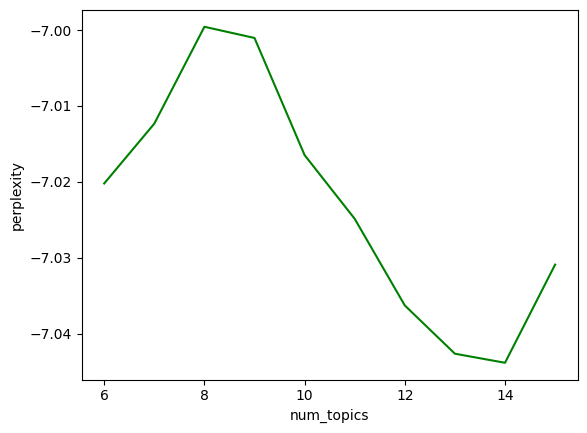

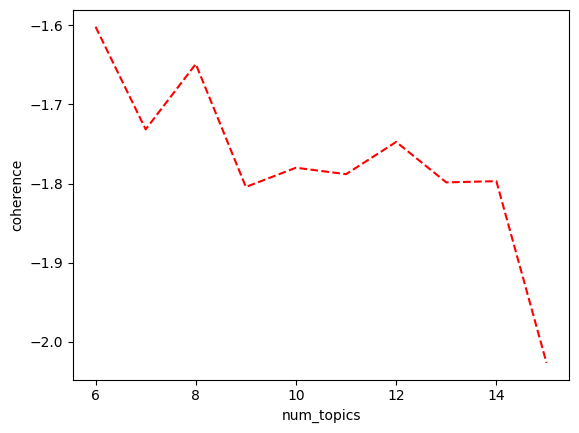

In [ ]:
def show_coherence(corpus, dictionary, start=6, end=15):
    iter_num = []
    per_value = []
    coh_value = []

    for i in range(start, end + 1):
        model = LdaModel(corpus=corpus, id2word=dictionary,
                 chunksize=1000, num_topics=i,
                 random_state=7)
        iter_num.append(i)
        pv = model.log_perplexity(corpus)
        per_value.append(pv)

        cm = CoherenceModel(model=model, corpus=corpus,
                            coherence='u_mass'
                            # coherence='c_v'
                            )
        cv = cm.get_coherence()
        coh_value.append(cv)
        print(f'num_topics: {i}, perplexity: {pv:0.3f}, coherence: {cv:0.3f}')

    plt.plot(iter_num, per_value, 'g-')
    plt.xlabel("num_topics")
    plt.ylabel("perplexity")
    plt.show()

    plt.plot(iter_num, coh_value, 'r--')
    plt.xlabel("num_topics")
    plt.ylabel("coherence")
    plt.show()

show_coherence(corpus, dictionary, start=6, end=15)

## 4. 토픽트렌드로 시간에 따른 주제의 변화 알아내기
- 한글: 청와대 국민청원 사이트의 만료된 청원 데이터 모음

1: https://github.com/akngs/petitions

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving petition_sampled.csv to petition_sampled.csv


In [ ]:
import pandas as pd

df = pd.read_csv("petition_sampled.csv")
print(df.shape)
df.head(1)

(18077, 8)


,article_id,start,end,answered,votes,category,title,content
0,58,2017-08-19,2017-11-17,0,21,일자리,국토교통부와 한국주택협회가 행한 부당한 행위와 권력남용에 대한 내용을 청원드립니다.,안녕하세요? 존경하고 지지하는 문재인 대통령님!\n저는 성남시 분당구 정자동 주택전...


In [ ]:
print(len(df.category.unique()))
print(df.category.unique())


17
['일자리' '보건복지' '육아/교육' '기타' '외교/통일/국방' '행정' '교통/건축/국토' '정치개혁' '안전/환경'
 '문화/예술/체육/언론' '경제민주화' '저출산/고령화대책' '농산어촌' '인권/성평등' '성장동력' '미래' '반려동물']


In [ ]:
!pip install konlpy

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from konlpy.tag import Okt #konlpy에서 Twitter 형태소 분석기를 import
twit = Okt()

def tokenizer(doc):
    return [token for token in twit.nouns(doc) if len(token) > 1]

vec = CountVectorizer(tokenizer=tokenizer, #우선은 명사만 사용
                      max_df=0.5, min_df = 5,
                      max_features = 1000) #적당한 대상 단어 수를 선택

pet_cv = vec.fit_transform(df.content)
print(pet_cv.shape)

(18077, 1000)


n_components: 10, perplexity: 584.099
n_components: 11, perplexity: 592.573
n_components: 12, perplexity: 589.209
n_components: 13, perplexity: 593.232
n_components: 14, perplexity: 595.239
n_components: 15, perplexity: 595.484
n_components: 16, perplexity: 602.762
n_components: 17, perplexity: 600.980
n_components: 18, perplexity: 606.504
n_components: 19, perplexity: 608.377
n_components: 20, perplexity: 609.218


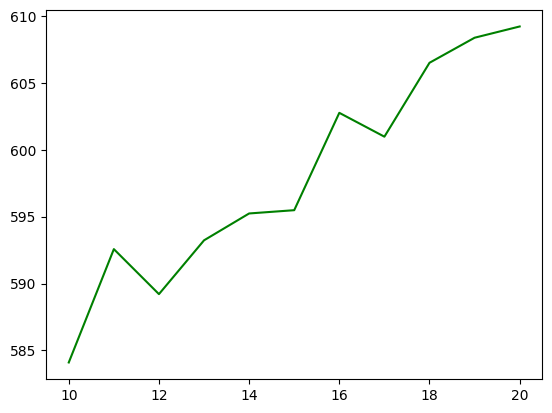

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


def show_perplexity(cv, start=10, end=30, max_iter=5, topic_word_prior= 0.1,doc_topic_prior=1.0):
    iter_num = []
    per_value = []

    for i in range(start, end + 1):
        lda = LatentDirichletAllocation(n_components = i,
                                        max_iter=max_iter,
                                        topic_word_prior= topic_word_prior,
                                        doc_topic_prior=doc_topic_prior,
                                        learning_method='batch',
                                        n_jobs= -1,
                                        random_state=7)
        lda.fit(cv)
        iter_num.append(i)
        pv = lda.perplexity(cv)
        per_value.append(pv)
        print(f'n_components: {i}, perplexity: {pv:0.3f}')

    plt.plot(iter_num, per_value, 'g-')
    plt.show()
    return start + per_value.index(min(per_value))

N_COMPONENTS = show_perplexity(pet_cv, start=10, end=20)


In [ ]:
print('N_COMPONENTS:',N_COMPONENTS)

N_COMPONENTS: 10


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components = N_COMPONENTS, \
                                n_jobs= -1, \
                                random_state=0)

pet_topics = lda.fit_transform(pet_cv)

def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print("Topic #%d: " % topic_idx, end='')
        print(", ".join([feature_names[i]
                         for i in topic.argsort()[:-n_top_words - 1:-1]]))
print_top_words(lda,vec.get_feature_names_out(), 10)

Topic #0: 처벌, 사건, 사람, 피해자, 생각, 범죄, 가해자, 수사, 피해, 대한
Topic #1: 북한, 정부, 한국, 미국, 우리, 일본, 중국, 문제, 화폐, 생각
Topic #2: 아이, 생각, 사람, 저희, 차량, 부모, 어린이집, 우리, 때문, 엄마
Topic #3: 청소년, 불법, 사회, 생각, 폐지, 보호, 이용, 장애인, 조직, 사람
Topic #4: 국민, 대통령, 나라, 사람, 대한민국, 생각, 우리, 정부, 국가, 지금
Topic #5: 정부, 정책, 주택, 부동산, 세금, 사람, 소득, 일자리, 아파트, 서민
Topic #6: 청원, 국민, 보험, 병원, 제도, 건강, 의료, 치료, 의사, 환자
Topic #7: 민원, 관리, 대한, 내용, 업무, 경우, 관련, 주민, 처리, 사용
Topic #8: 학생, 학교, 교육, 생각, 선수, 시험, 대학, 교사, 공부, 문제
Topic #9: 경찰, 여성, 공무원, 연금, 국민, 국민연금, 남성, 범죄, 위해, 대한민국


> 시간의 흐름에 따른 토픽 변화(트렌드)를 분석
- LDA 토픽 모델링 결과(각 문서가 어떤 토픽에 속할 확률)를 날짜 데이터와 합침

In [ ]:
print(pet_topics.shape)

trend_data = pd.DataFrame(pet_topics, columns=['Topic'+str(i) for i in range(1, N_COMPONENTS+1)])
trend_data = pd.concat([trend_data, df.start.map(lambda x: x[:7])], axis=1)
# trend_data.iloc[:5, -5:]
print(trend_data.head())

(18077, 10)
     Topic1    Topic2    Topic3    Topic4    Topic5    Topic6    Topic7  \
0  0.000461  0.000461  0.000461  0.000461  0.054760  0.144459  0.000461   
1  0.001205  0.001205  0.645606  0.001205  0.001205  0.122491  0.001205   
2  0.002223  0.002222  0.002223  0.002223  0.002223  0.002223  0.002223   
3  0.017804  0.524537  0.021494  0.065144  0.211341  0.158319  0.000340   
4  0.028532  0.188296  0.000671  0.047944  0.441491  0.000671  0.174123   

     Topic8    Topic9   Topic10    start  
0  0.797555  0.000461  0.000461  2017-08  
1  0.001205  0.156170  0.068502  2017-08  
2  0.002223  0.979996  0.002223  2017-08  
3  0.000340  0.000340  0.000340  2017-08  
4  0.047708  0.000671  0.069892  2017-08  


In [ ]:
trend = trend_data.groupby(['start']).mean()
# trend.iloc[:5, -5:]
print(trend.head())

           Topic1    Topic2    Topic3    Topic4    Topic5    Topic6    Topic7  \
start                                                                           
2017-08  0.075126  0.074433  0.197675  0.039065  0.114605  0.170840  0.058991   
2017-09  0.188508  0.054469  0.119211  0.277101  0.088361  0.058304  0.051373   
2017-10  0.105755  0.083637  0.133384  0.081232  0.120220  0.122086  0.068703   
2017-11  0.133788  0.217914  0.078893  0.051247  0.129538  0.065251  0.102241   
2017-12  0.118971  0.083743  0.118257  0.070327  0.146536  0.137194  0.081795   

           Topic8    Topic9   Topic10  
start                                  
2017-08  0.136077  0.113809  0.019380  
2017-09  0.060212  0.071823  0.030637  
2017-10  0.099604  0.118526  0.066853  
2017-11  0.082366  0.086916  0.051847  
2017-12  0.112840  0.091722  0.038616  


In [ ]:
print(trend.index)


Index(['2017-08', '2017-09', '2017-10', '2017-11', '2017-12', '2018-01',
       '2018-02', '2018-03', '2018-04', '2018-05', '2018-06', '2018-07',
       '2018-08', '2018-09', '2018-10', '2018-11', '2018-12'],
      dtype='object', name='start')


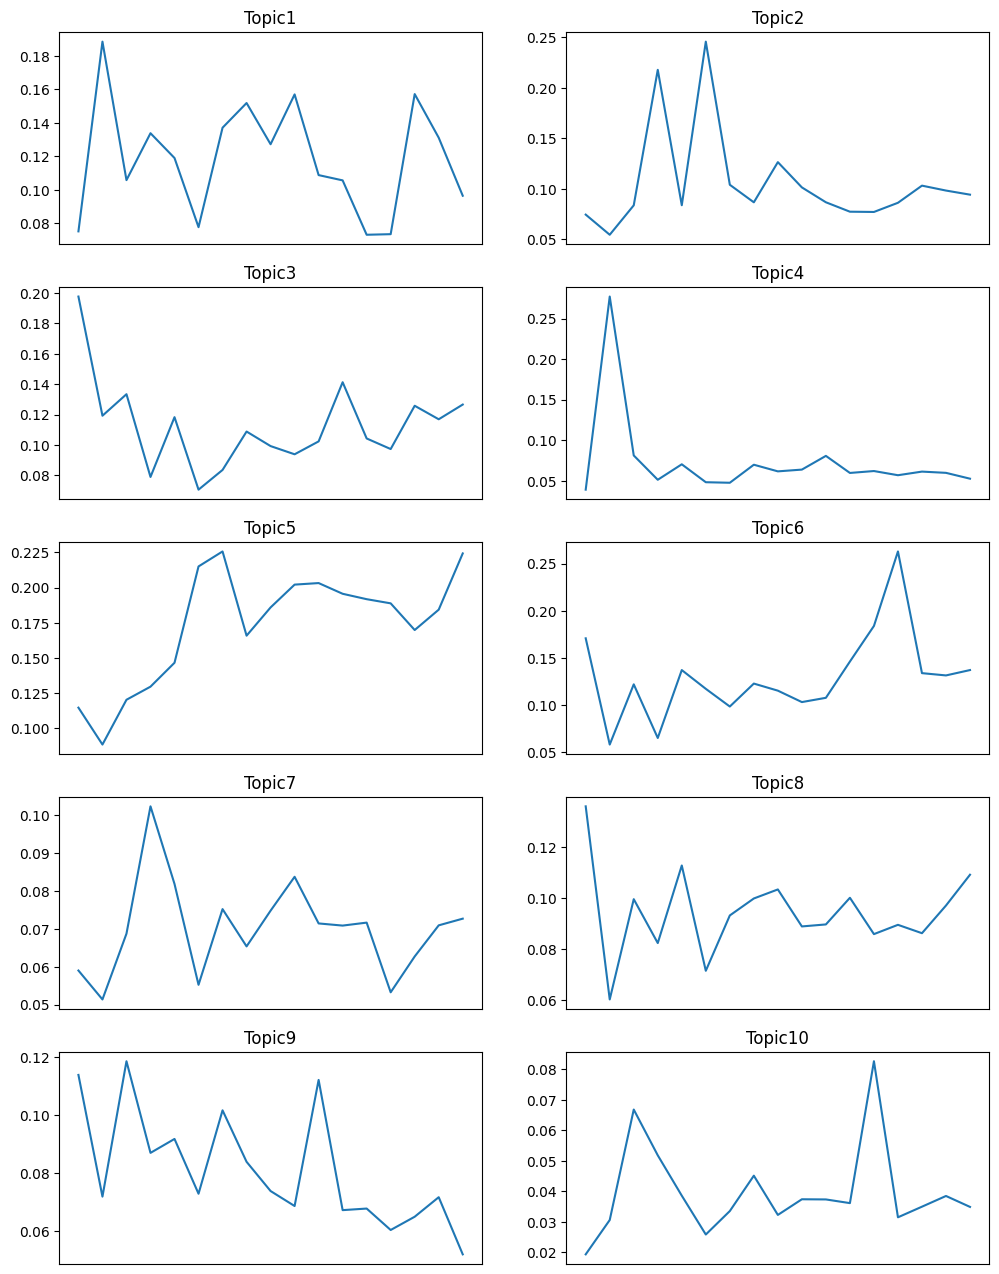

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

fig, axes = plt.subplots(5, 2, sharex='col', figsize=(12, 16))
for col, ax in zip(trend.columns.tolist(), axes.ravel()):
    ax.set_title(col)
    ax.axes.xaxis.set_visible(False)
    ax.plot(trend[col])
plt.show()